# Tutorial 1: Fitting LC Models to a CPW

`simpleLOMs` replaces a distributed coplanar-waveguide (CPW) resonator with a
single lumped `L`–`C` oscillator that you can drop into a circuit Hamiltonian.
This tutorial fits the three models the package ships with to one CPW device and
**ranks them against the CPW ground truth**, so you can see why the *Optimized*
model is the default.

The device here is in the strongly, asymmetrically coupled
regime ($C_{c1}=30$ fF, $C_{c2}=70$ fF) which allows us to compare the accuracy of the three lumped
       models in a realistic scenario.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

from pathlib import Path

from simpleLOMs import (
    CPWParams, FosterFit, OptimizedFit, AnalyticalFit,
    analyze_system, fit_lom, utils,
    plot_re_im, plot_all_models, plot_residuals,
    plot_summary, plot_transmission, plot_scan,
)
from simpleLOMs.networks.cpw import cpw_resonator_network_2port
from simpleLOMs.analysis import circle_fit_f0_kappa
from simpleLOMs.models.optimized_fit import OptimizationConfig
from simpleLOMs.schematics import lc_schematic_2port

print("All imports OK")


All imports OK


---
## 1. Load your CPW

The CPW geometry lives in a `CPWParams` dataclass, which is defined once and passed
into every function that needs it.


In [3]:
cpw_params = CPWParams(
    w=11.7e-6,              # center-conductor width (m)
    s=5.1e-6,               # gap spacing (m)
    t=0.0,                  # metal thickness — 0 = ideal thin film
    h=500e-6,               # substrate height (m)
    rho=1e-19,              # resistivity ~ 0 -> superconducting limit
    ep_r=11.45,             # relative permittivity (ultracold silicon)
    has_metal_backside=True,
    tand=0.0,               # lossless substrate
)

print(cpw_params)


CPWParams(w=1.17e-05, s=5.1e-06, t=0.0, h=0.0005, rho=1e-19, ep_r=11.45, has_metal_backside=True, tand=0.0)


Next we set the circuit-level parameters: the resonator length `d`, the
reference (feedline) impedance `Z0`, and the coupling / ground capacitances. In
practice we recommend extracting `Cc1, Cc2, Ctog1, Ctog2` from the Maxwell
capacitance matrices of your EM solver of choice (e.g. $\texttt{ANSYS HFSS}$,
$\texttt{COMSOL}$).

A single reference impedance $Z_0 = 50\,\Omega$ is used throughout the notebook.


In [4]:
d     = 7.0e-3    # resonator length (m) 
Z0    = 50.0      # reference / feedline impedance (ohm) — used everywhere

Cc1   = 3.0e-14   # coupling capacitor, port 1 (F)   -> 30 fF
Cc2   = 7.0e-14   # coupling capacitor, port 2 (F)   -> 70 fF  (asymmetric!)
Ctog1 = 4.0e-14   # shunt-to-ground cap, port 1 (F)
Ctog2 = 6.0e-14   # shunt-to-ground cap, port 2 (F)


We may also define load resonators. These are not needed for the initial fit,
but they let us check the hybridized frequency shift the model predicts once
these loads are attached (Section 3). To approximate the case of a qubit-bus resonator, for example,
we pick two loads near a typical
qubit frequency ($3$–$5$ GHz).


In [5]:
Lload1 = 2e-09    # load 1 inductance (H)
Cload1 = 6.0e-13  # load 1 capacitance (F)
Lload2 = 4e-09    # load 2 inductance (H)
Cload2 = 6.0e-13  # load 2 capacitance (F)

f_load1 = 1.0 / (2 * np.pi * np.sqrt(Lload1 * Cload1)) / 1e9
f_load2 = 1.0 / (2 * np.pi * np.sqrt(Lload2 * Cload2)) / 1e9
print(f"Load 1 bare resonance: {f_load1:.4f} GHz")
print(f"Load 2 bare resonance: {f_load2:.4f} GHz")


Load 1 bare resonance: 4.5944 GHz
Load 2 bare resonance: 3.2487 GHz


Finally we choose a coarse frequency grid spanning the resonance. The individual fits
below refine their own windows around $f_0$.


In [6]:
freq = rf.Frequency(6e9, 9e9, 400_001, unit="Hz")


### 1a. Inspect the CPW network

Build the 2-port CPW network and read off its resonance with the package's
circle fit.


In [7]:
cpw_net = cpw_resonator_network_2port(
    freq, d, Cc1, Cc2, Ctog1, Ctog2,
    cpw_params=cpw_params, Z0=Z0,
)

f0_s11, k_s11 = circle_fit_f0_kappa(cpw_net, 0, 0)
f0_s22, k_s22 = circle_fit_f0_kappa(cpw_net, 1, 1)
print(f"CPW  S11:  f0 = {f0_s11/1e9:.4f} GHz    kappa/2pi = {k_s11/1e6:.3f} MHz")
print(f"CPW  S22:  f0 = {f0_s22/1e9:.4f} GHz    kappa/2pi = {k_s22/1e6:.3f} MHz")


CPW  S11:  f0 = 7.4301 GHz    kappa/2pi = 128.921 MHz
CPW  S22:  f0 = 7.4302 GHz    kappa/2pi = 128.141 MHz


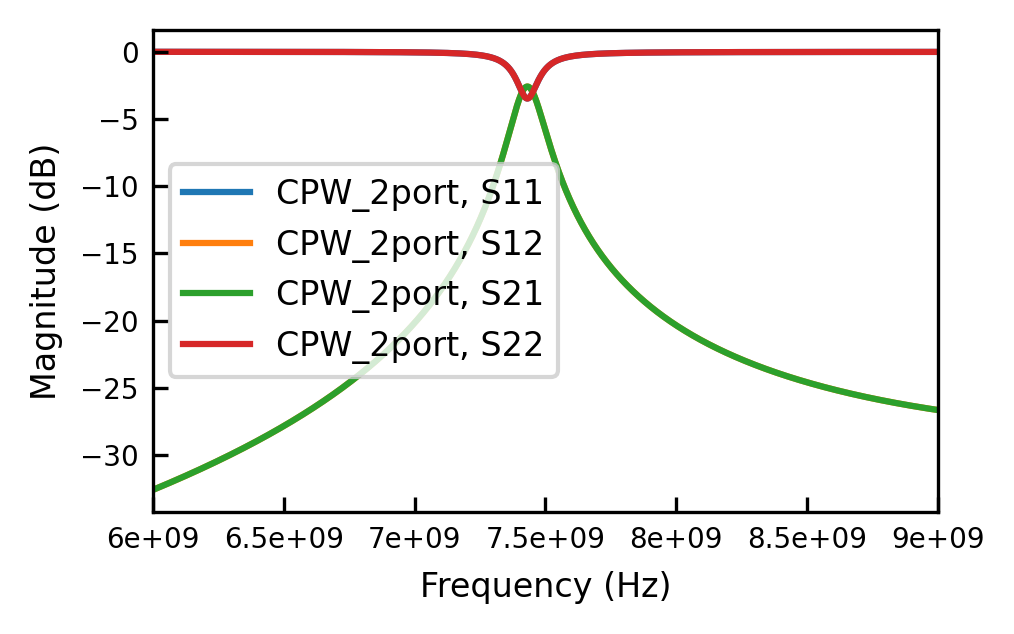

In [8]:
cpw_net.plot_s_db()
plt.show()


We can also look at $\mathrm{Re}(S)$ and $\mathrm{Im}(S)$ to get a feel for the lineshape.


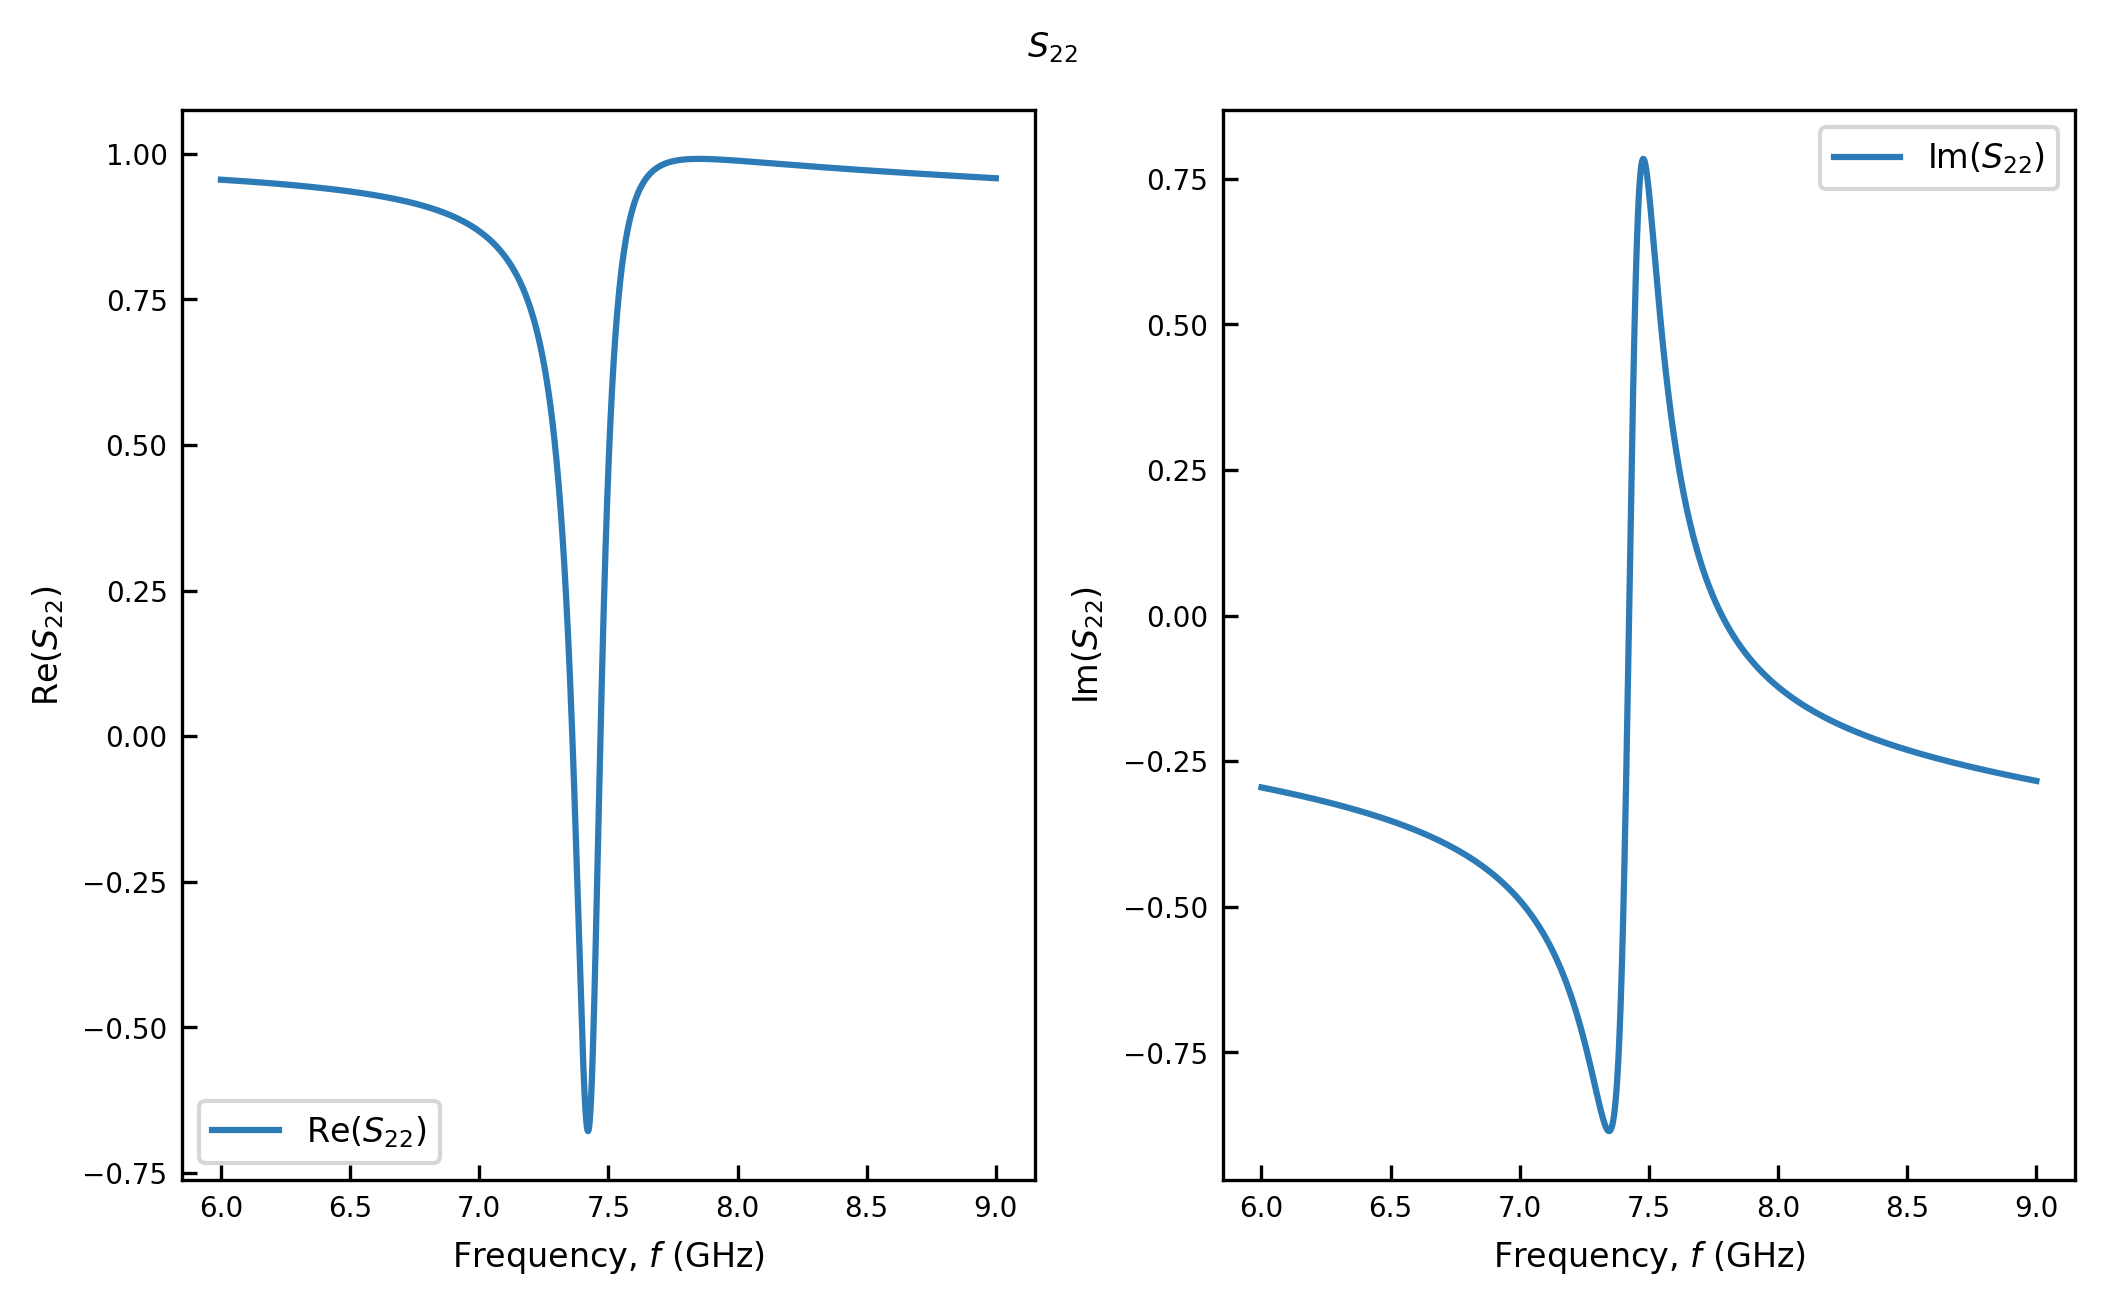

In [9]:
plot_re_im(cpw_net, m=1, n=1, title=r"$S_{22}$")
plt.show()


---
## 2. Fitting each model individually

`simpleLOMs` contains three lumped models:

1. **`AnalyticalFit`** — closed form (for a $\lambda/2$ resonator)
2. **`FosterFit`** — Foster synthesis from the line's admittance slope
   (Used in `PhysRevLett.108.240502`).
3. **`OptimizedFit`** — our numerical fit of $L_\mathrm{eff}, C_\mathrm{eff}$ to
   the CPW $S$-parameters, with the coupling capacitors included.

Each model follows the same three-step pattern:

```python
model = ModelClass(...)                       # 1. instantiate
model.fit(freq, ...)                          # 2. run the fit
net = model.get_network(refined_freq, ...)    # 3. build the fitted network
```

To rank them fairly we build one CPW reference and score every model
against it using `circle_fit_f0_kappa`.


In [10]:
# One refined CPW reference; every model is scored against it the same way.
refined_freq = rf.Frequency(f0_s11 - 0.5e9, f0_s11 + 0.5e9, 20_001, unit="Hz")
cpw_ref = cpw_resonator_network_2port(
    refined_freq, d, Cc1, Cc2, Ctog1, Ctog2,
    cpw_params=cpw_params, Z0=Z0,
)
f0_cpw, k_cpw = circle_fit_f0_kappa(cpw_ref, 0, 0)
print(f"CPW ground truth:  f0 = {f0_cpw/1e9:.4f} GHz    kappa/2pi = {k_cpw/1e6:.3f} MHz")


def score(name, net):
    "Circle-fit a fitted LOM network and print its signed error vs the CPW."
    f0, k = circle_fit_f0_kappa(net, 0, 0)
    print(f"{name:11s} f0 = {f0/1e9:.4f} GHz  (err {(f0-f0_cpw)/f0_cpw*100:+.3f}%)"
          f"    kappa/2pi = {k/1e6:.3f} MHz  (err {(k-k_cpw)/k_cpw*100:+.2f}%)")
    return f0, k


CPW ground truth:  f0 = 7.4301 GHz    kappa/2pi = 128.455 MHz


### 2a. AnalyticalFit

`AnalyticalFit` uses two closed-form expressions,

$$C_\mathrm{eff} = \frac{\pi}{2\,Z_0^{\mathrm{cpw}}\,\omega_{\lambda/2}}, \qquad
  L_\mathrm{eff} = \frac{1}{\omega_{\lambda/2}^2\, C_\mathrm{eff}},$$

so it needs an **unloaded** resonance frequency and the CPW **characteristic
impedance** $Z_0^{\mathrm{cpw}}$. Here
$Z_0^{\mathrm{cpw}} = 45.926\,\Omega$ and the unloaded $f_r = 8.58$ GHz; both are
readable from scikit-rf or TXLine.


AnalyticalFit(L=5.4234e-10 H, C=6.3445e-13 F, f_r=8.5800 GHz)


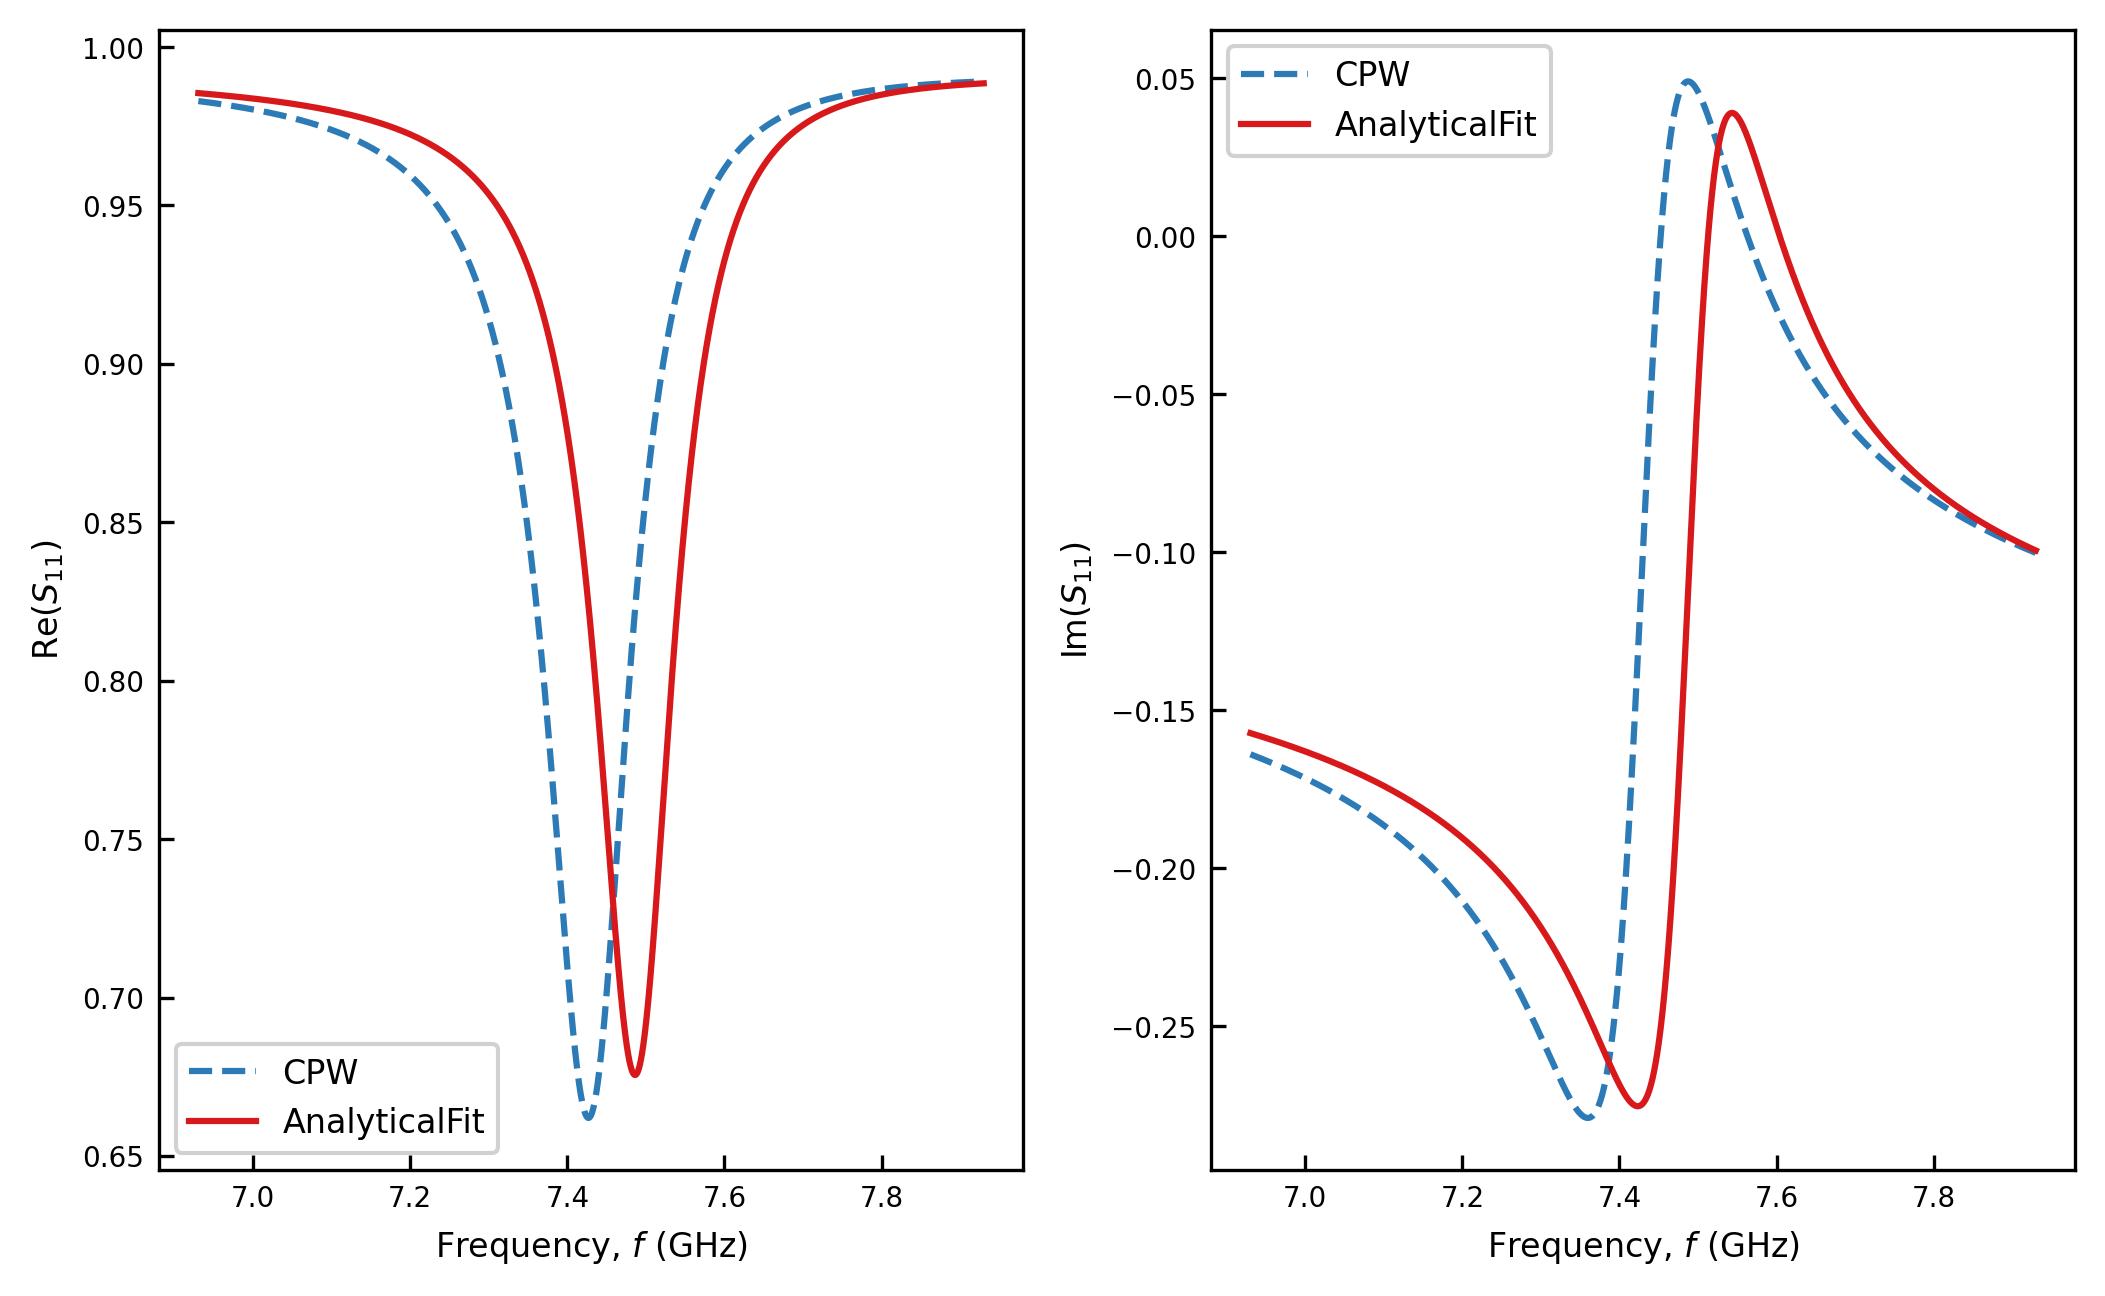

Analytical  f0 = 7.4892 GHz  (err +0.794%)    kappa/2pi = 120.711 MHz  (err -6.03%)


(7489157180.047385, 120711475.20221901)

In [11]:
Z0_cpw = 45.926      # CPW characteristic impedance (geometry) — NOT the 50 ohm ref
f0_unloaded = 8.58e9 # unloaded lambda/2 resonance

analytical = AnalyticalFit(mode=2)   # mode=2 -> lambda/2 (default)
analytical.fit(refined_freq, f_r=f0_unloaded, Z0=Z0_cpw)
print(analytical)

analytical_net = analytical.get_network(
    refined_freq, Cc1=Cc1, Cc2=Cc2, Ctog1=Ctog1, Ctog2=Ctog2, Z0=Z0,
    reference=cpw_ref, show=True, m=0, n=0,
    lom_label="AnalyticalFit", data_label="CPW",
)
plt.show()
score("Analytical", analytical_net)


### 2b. FosterFit

`FosterFit` extracts `L` and `C` from the admittance slope
$\mathrm{d}B/\mathrm{d}\omega$ at the CPW resonance. It needs only the resonator
length `d` and the CPW geometry — no measured $S$-parameters.


FosterFit(L=5.5275e-10 H, C=6.2215e-13 F, f0=8.5824 GHz)


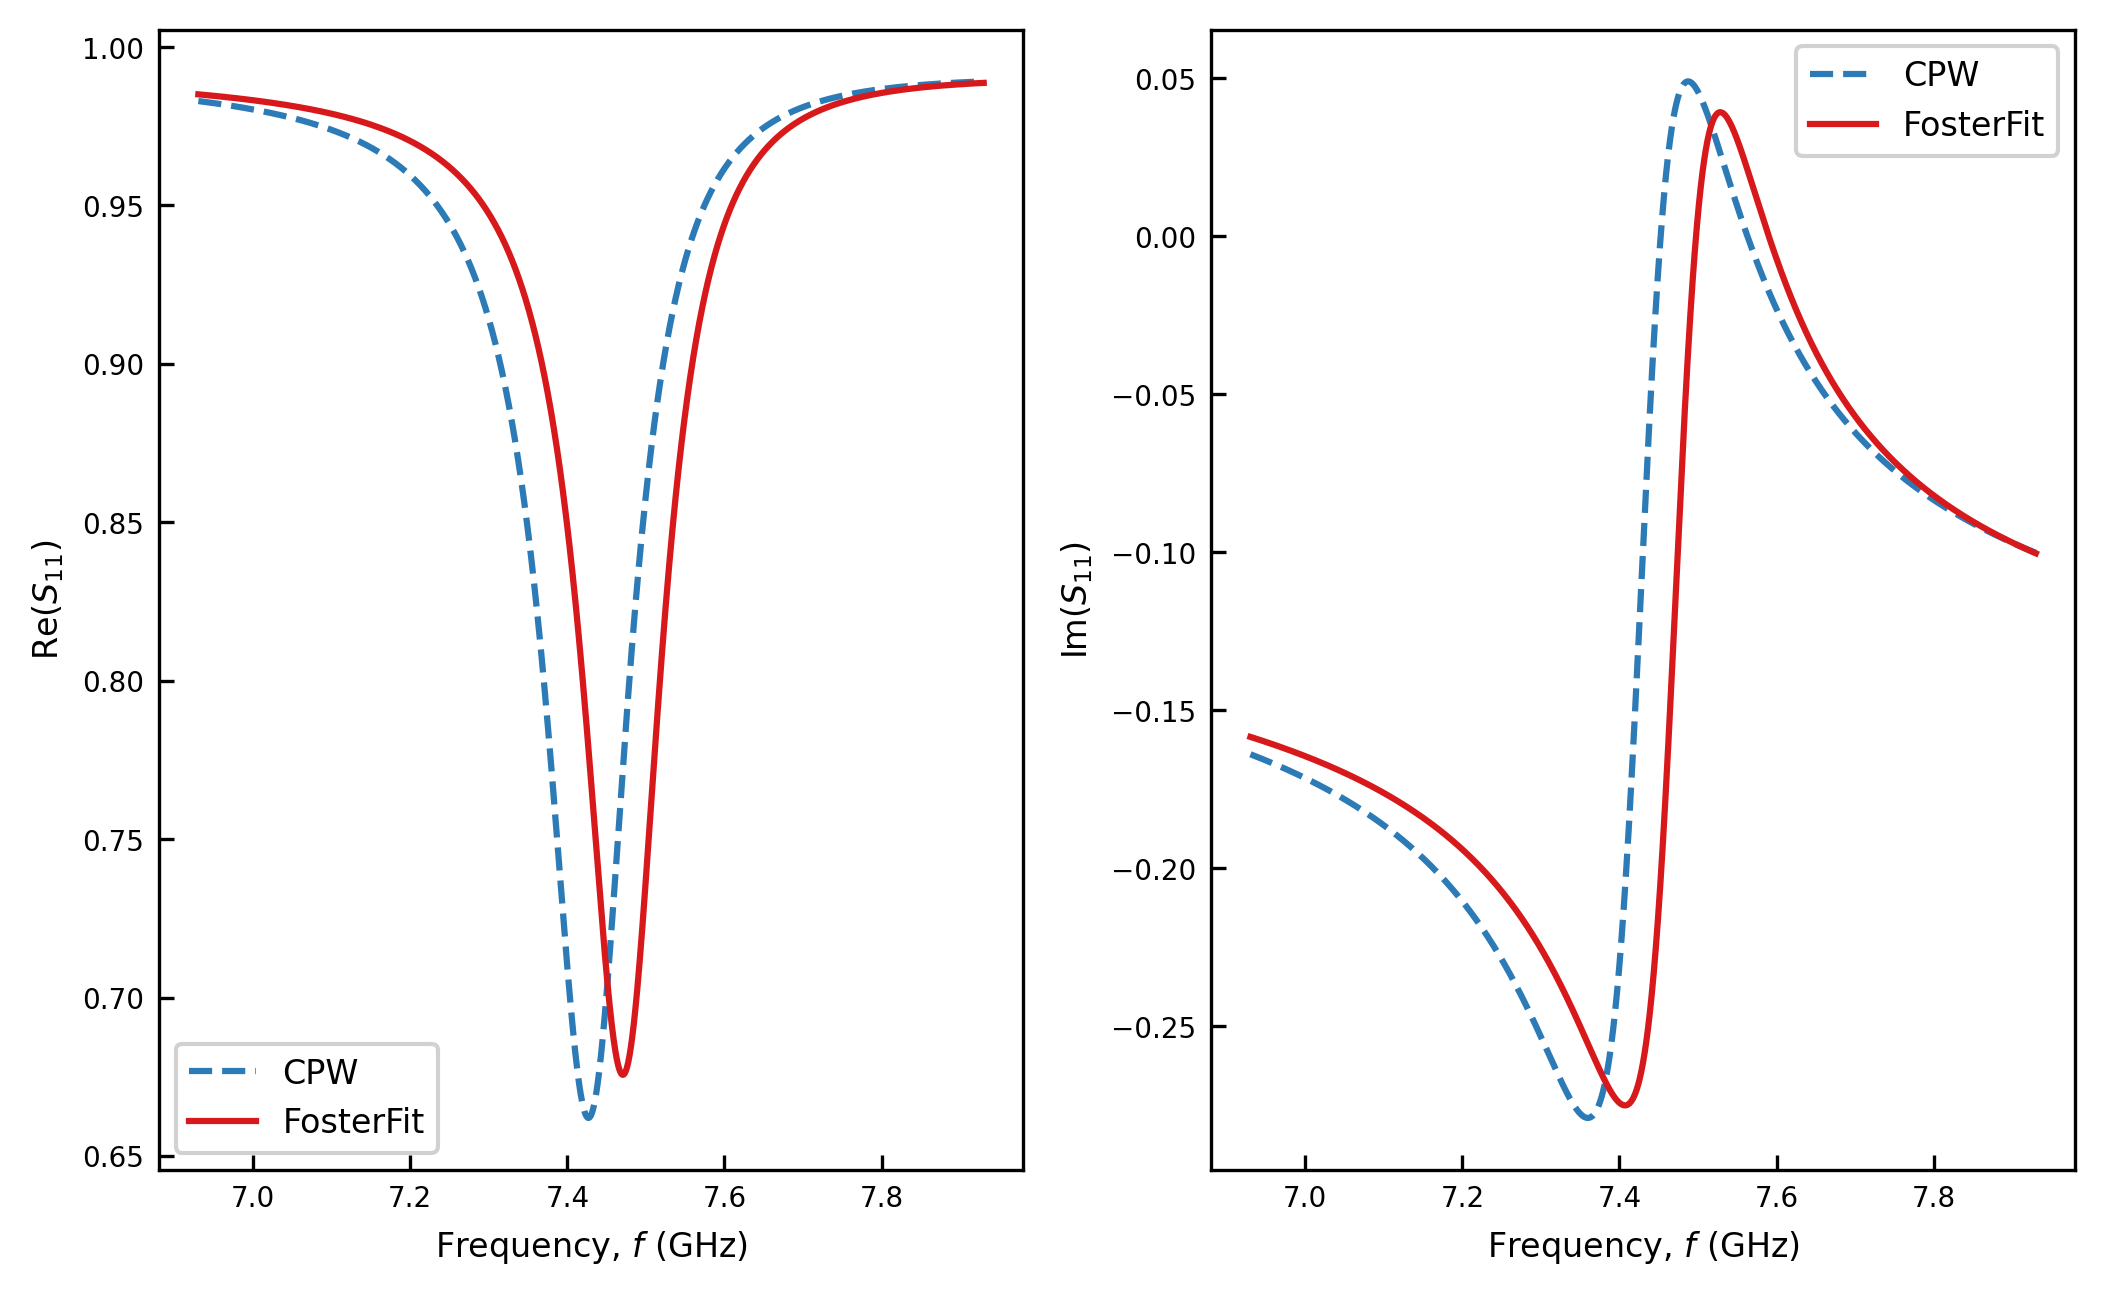

Foster      f0 = 7.4736 GHz  (err +0.585%)    kappa/2pi = 122.021 MHz  (err -5.01%)


(7473615023.54162, 122020731.34065533)

In [12]:
foster = FosterFit(cpw_params=cpw_params)
foster.fit(freq, d=d)
print(foster)

foster_net = foster.get_network(
    refined_freq, Cc1=Cc1, Cc2=Cc2, Ctog1=Ctog1, Ctog2=Ctog2, Z0=Z0,
    reference=cpw_ref, show=True, m=0, n=0,
    lom_label="FosterFit", data_label="CPW",
)
plt.show()
score("Foster", foster_net)


### 2c. OptimizedFit

`OptimizedFit` runs two stages of numerical optimisation against the CPW $S_{11}$
and $S_{22}$, with the coupling capacitors held fixed. It takes the CPW network
as input.

The default settings nearly always outperform `FosterFit` and `AnalyticalFit`.
When you do want to tune the optimiser, you can change settings in`OptimizationConfig`. THe settings are:

1. **`w0_window_frac`** — how tightly the Stage-1 scan brackets $\omega_0$. Use
   $\sim 0.0001$ for *localized* behaviour at resonance; relax to $\sim
   0.005$–$0.05$ for *broadband* behaviour across a wide span.
2. **`n_w0`** — number of Stage-1 scan points for the initial $\omega_0$ guess.
   $\sim 10$–$20$ is plenty (it is refined later).
3. **`n_dense`** — number of Stage-1 optimisation points; $\lesssim 100$ keeps
   runtime down.
4. **`n_widths`** — the Stage-2 window in units of linewidth, e.g.
   `n_widths=3` fits over $\pm 3\kappa$ about $\omega_r$.

For localized behaviour set `w0_window_frac` $\sim 0.0001$ and `n_widths`
$\sim 1$. For broadband behaviour, it is best to relax these both.


OptimizedFit(L=5.9105e-10 H, C=6.7795e-13 F)
L = 5.9105e-10 H    C = 6.7795e-13 F


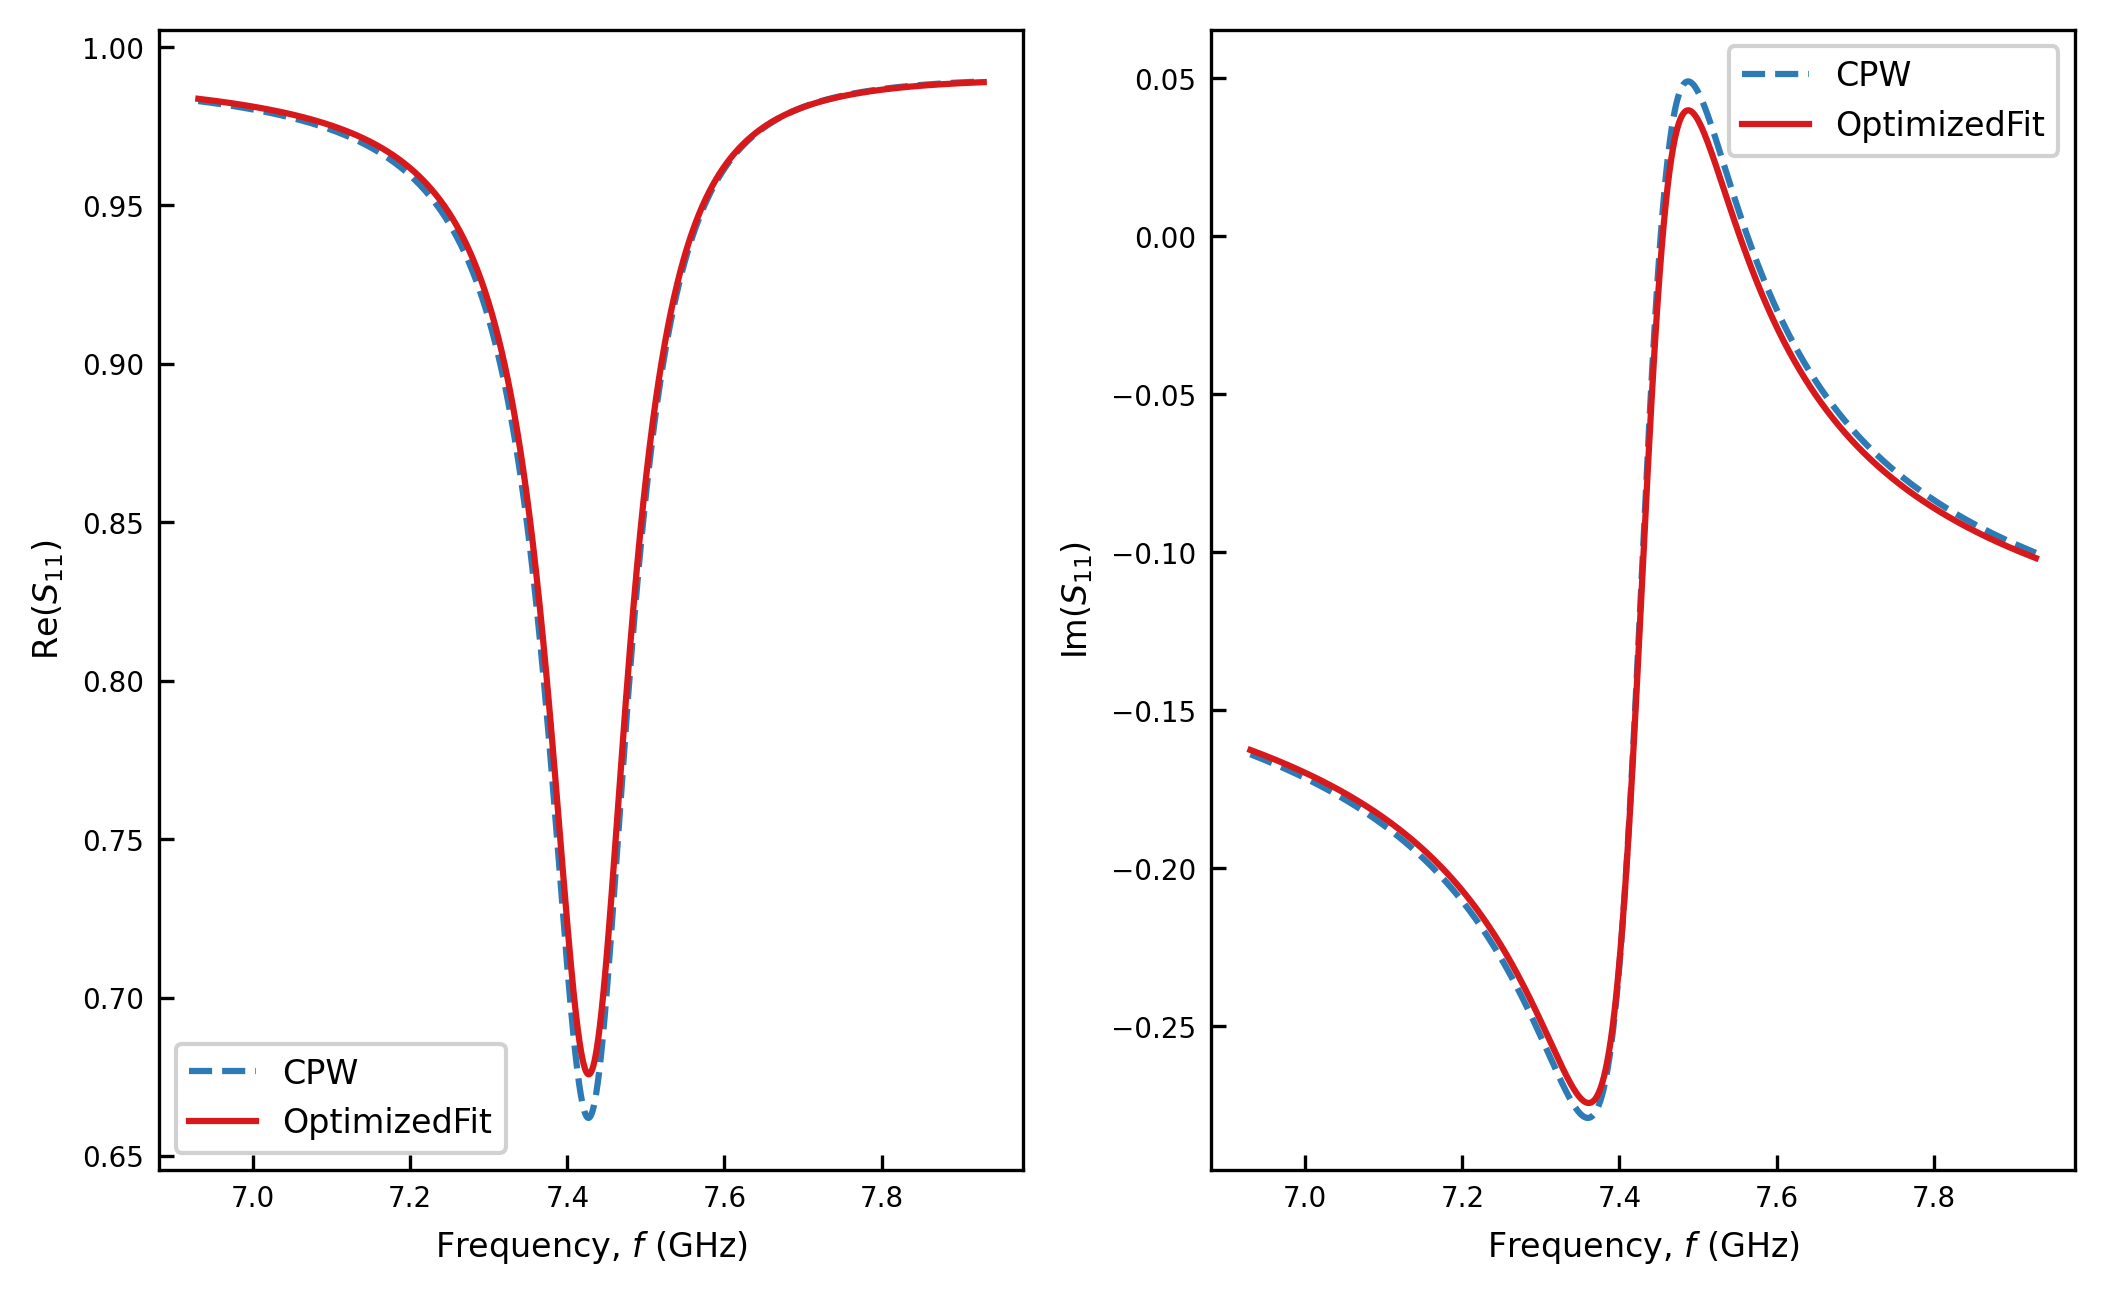

Optimized   f0 = 7.4302 GHz  (err +0.001%)    kappa/2pi = 127.512 MHz  (err -0.73%)


(7430198159.717065, 127511817.87388897)

In [13]:
config = OptimizationConfig(
    w0_window_frac=0.0001,
    n_w0=10,
    n_dense=10,
    n_widths=3.0,
    verbose=False,       # set True to watch the least-squares iterations
)

optimized = OptimizedFit(config=config)
optimized.fit(
    refined_freq, data_ntw=cpw_ref,
    Cc1=Cc1, Cc2=Cc2, Ctog1=Ctog1, Ctog2=Ctog2,
    d=d, cpw_params=cpw_params, Z0=Z0,
)
params = optimized.get_params()
print(optimized)
print(f"L = {params['L']:.4e} H    C = {params['C']:.4e} F")

optimized_net = optimized.get_network(
    refined_freq, Cc1=Cc1, Cc2=Cc2, Z0=Z0,
    reference=cpw_ref, show=True, m=0, n=0,
    lom_label="OptimizedFit", data_label="CPW",
)
plt.show()
score("Optimized", optimized_net)


The optimiser minimises the  complex residuals (real and
imaginary parts) of $S_{11}$ and $S_{22}$ over a window of $\pm n_\mathrm{widths}\,\kappa$
around each resonance (here we choose `n_widths=3`). 

To confirm that the optimized fit worked,  `plot_scan` shows the Stage-1
$\omega_0$ scan found a clean minimum, and `plot_residuals` shows the leftover
$S$-parameter mismatch across the band.


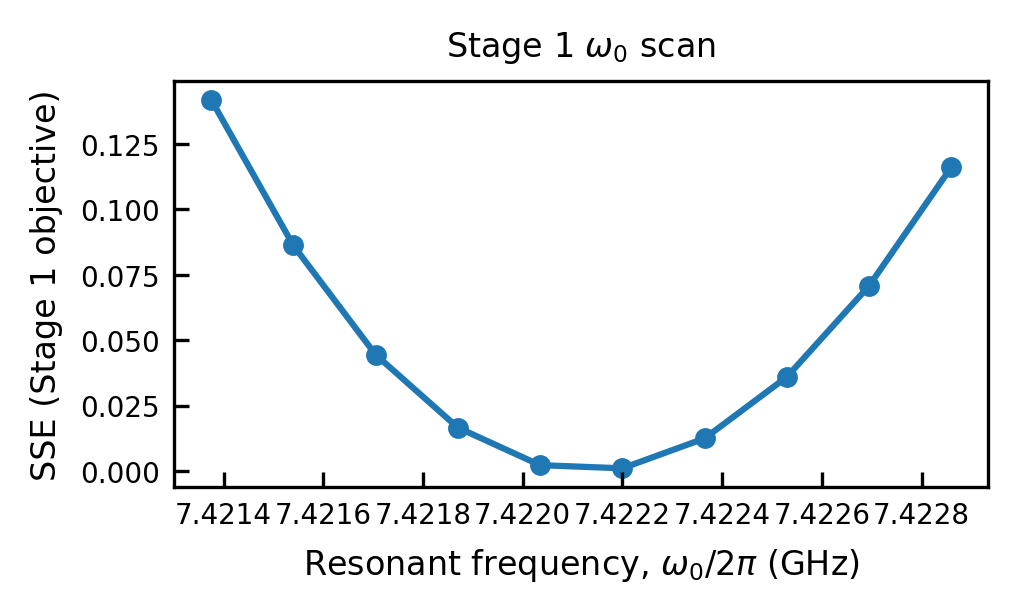

In [14]:
plot_scan(optimized)
plt.show()


Saved: figures/residuals_s11.pdf


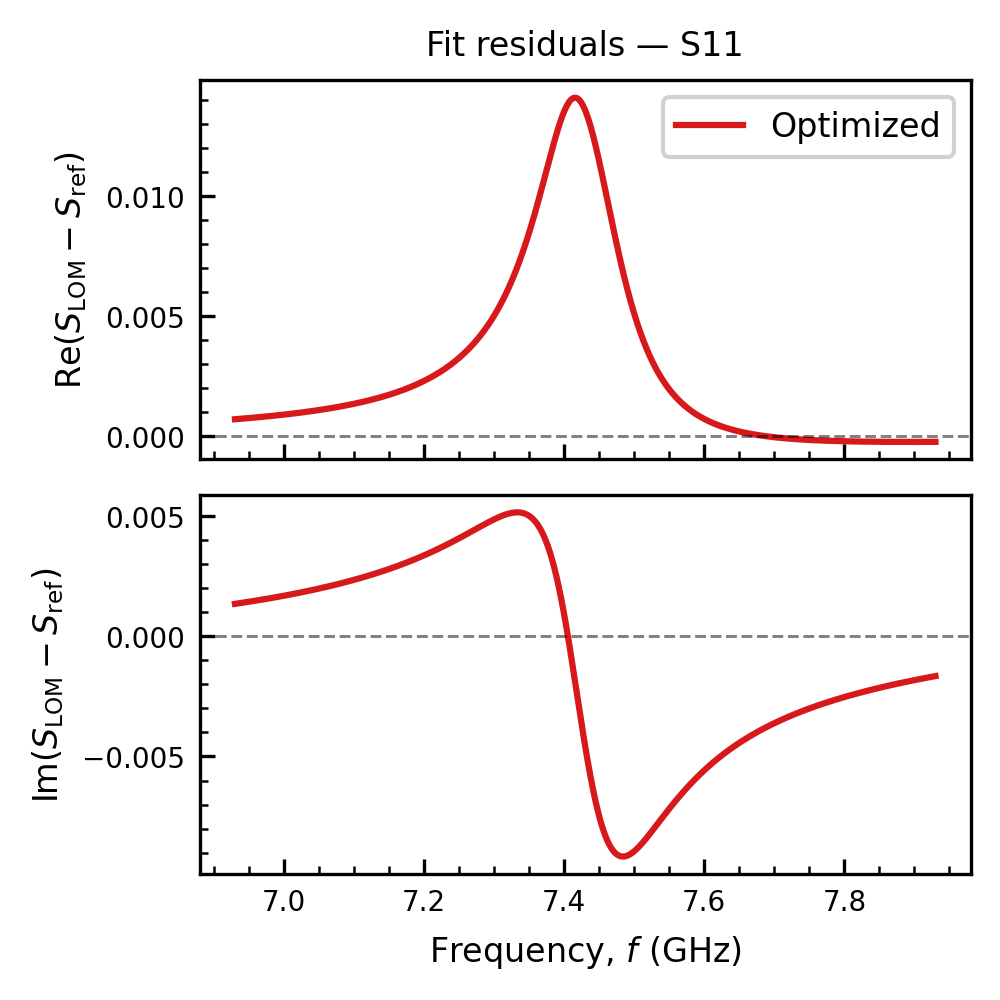

In [15]:
plot_residuals(
    data_ntw=cpw_ref,
    lom_networks={"optimized": optimized_net},
    m=0, n=0,   # S11
    save_path="figures/residuals_s11.pdf",
)
plt.show()


### 2d. Side-by-side overlay

`plot_all_models` puts all four networks on one axes so you can visually rank the
methods.


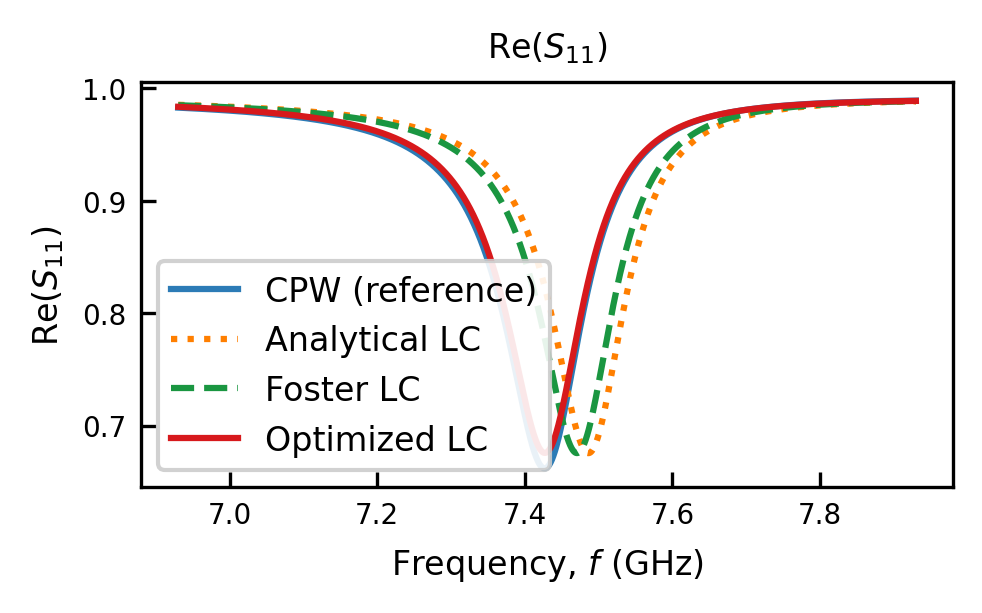

In [16]:
plot_all_models(
    {
        "CPW (reference)": cpw_ref,
        "Analytical LC":   analytical_net,
        "Foster LC":       foster_net,
        "Optimized LC":    optimized_net,
    },
    m=0, n=0, quantity="re",
    title=r"$\mathrm{Re}(S_{11})$",
)
plt.show()


In this regime, the **Optimized** method is the clear winner. Its resonance sits within a few thousandths
of a percent of the CPW ground truth and its linewidth within about one percent,
while Foster and Analytical drift by roughly half a percent to a percent in
frequency and several percent in linewidth. This is exactly the strong,
asymmetric-coupling regime ($C_{c1}=30$ fF, $C_{c2}=70$ fF) where fitting with
the coupling capacitors included is important.


---
## 3. Full system comparison in one call

`analyze_system()` runs all three fits for you, extracts $f_0$ and $\kappa$ from
$S_{11}$ and $S_{22}$ with circle fits, and,  because we pass the loads defined in the beginning, also
builds a loaded network and reports the hybridized frequency shifts against
the CPW. It returns a `results` dict holding every fitted model, network, and
error metric.


In [17]:
freq_sys = rf.Frequency(5e9, 10e9, 300_001, unit="Hz")

results = analyze_system(
    freq=freq_sys,
    d=d,
    Cc1=Cc1, Cc2=Cc2,
    Ctog1=Ctog1, Ctog2=Ctog2,
    Lload1=Lload1, Cload1=Cload1,
    Lload2=Lload2, Cload2=Cload2,
    cpw_params=cpw_params,
    Z0=Z0,                 # same 50 ohm reference as above
    analytical_Z0=Z0_cpw,  # CPW characteristic impedance for the analytical formula
    verbose=False,
)

print("analyze_system() complete.")
print("Result keys:", [k for k in results
                       if not isinstance(results[k],
                                         (rf.Network, FosterFit, OptimizedFit, AnalyticalFit))][:12], "...")


analyze_system() complete.
Result keys: ['Z0 (Ohms)', 'Cc1 (F)', 'Cc2 (F)', 'Ctog1 (F)', 'Ctog2 (F)', 'Optimized L (H)', 'Optimized C (F)', 'Foster L (H)', 'Foster C (F)', 'Analytical L (H)', 'Analytical C (F)', 'CPW f0 S11 (GHz)'] ...


### 3a. Results as tables


In [18]:
utils.make_results_table(results)


,f0 S11 (GHz),κ S11 (MHz),f0 S22 (GHz),κ S22 (MHz),f0 error S11 (%),κ error S11 (%),f0 error S22 (%),κ error S22 (%)
Method,,,,,,,,
CPW,7.4301,128.4978,7.4302,128.1283,NaN,NaN,NaN,NaN
Optimized,7.4302,127.5310,7.4303,127.1505,-0.0009,0.7524,-0.0011,0.7631
Foster,7.4736,122.0642,7.4736,121.6878,-0.5846,5.0068,-0.5847,5.0266
Analytical,7.4910,120.8367,7.4910,120.4568,-0.8189,5.9620,-0.8190,5.9873


In [19]:
utils.make_params_table(results)


,L (H),C (F)
Model,,
Foster,5.527729e-10,6.221275e-13
Optimized,5.909357e-10,6.780946e-13
Analytical,5.421902e-10,6.342700e-13


Here we can see the `f0 error` and `kappa error` columns for all three models. 
       Optimized is the best performing model, while Foster comes second and
Analytical last. 


### 3b. Plotting the results

The `results` dict stores the fitted networks, so you can plot various metrics of interest without rerunning
anything.


Saved: figures/fit_summary.pdf


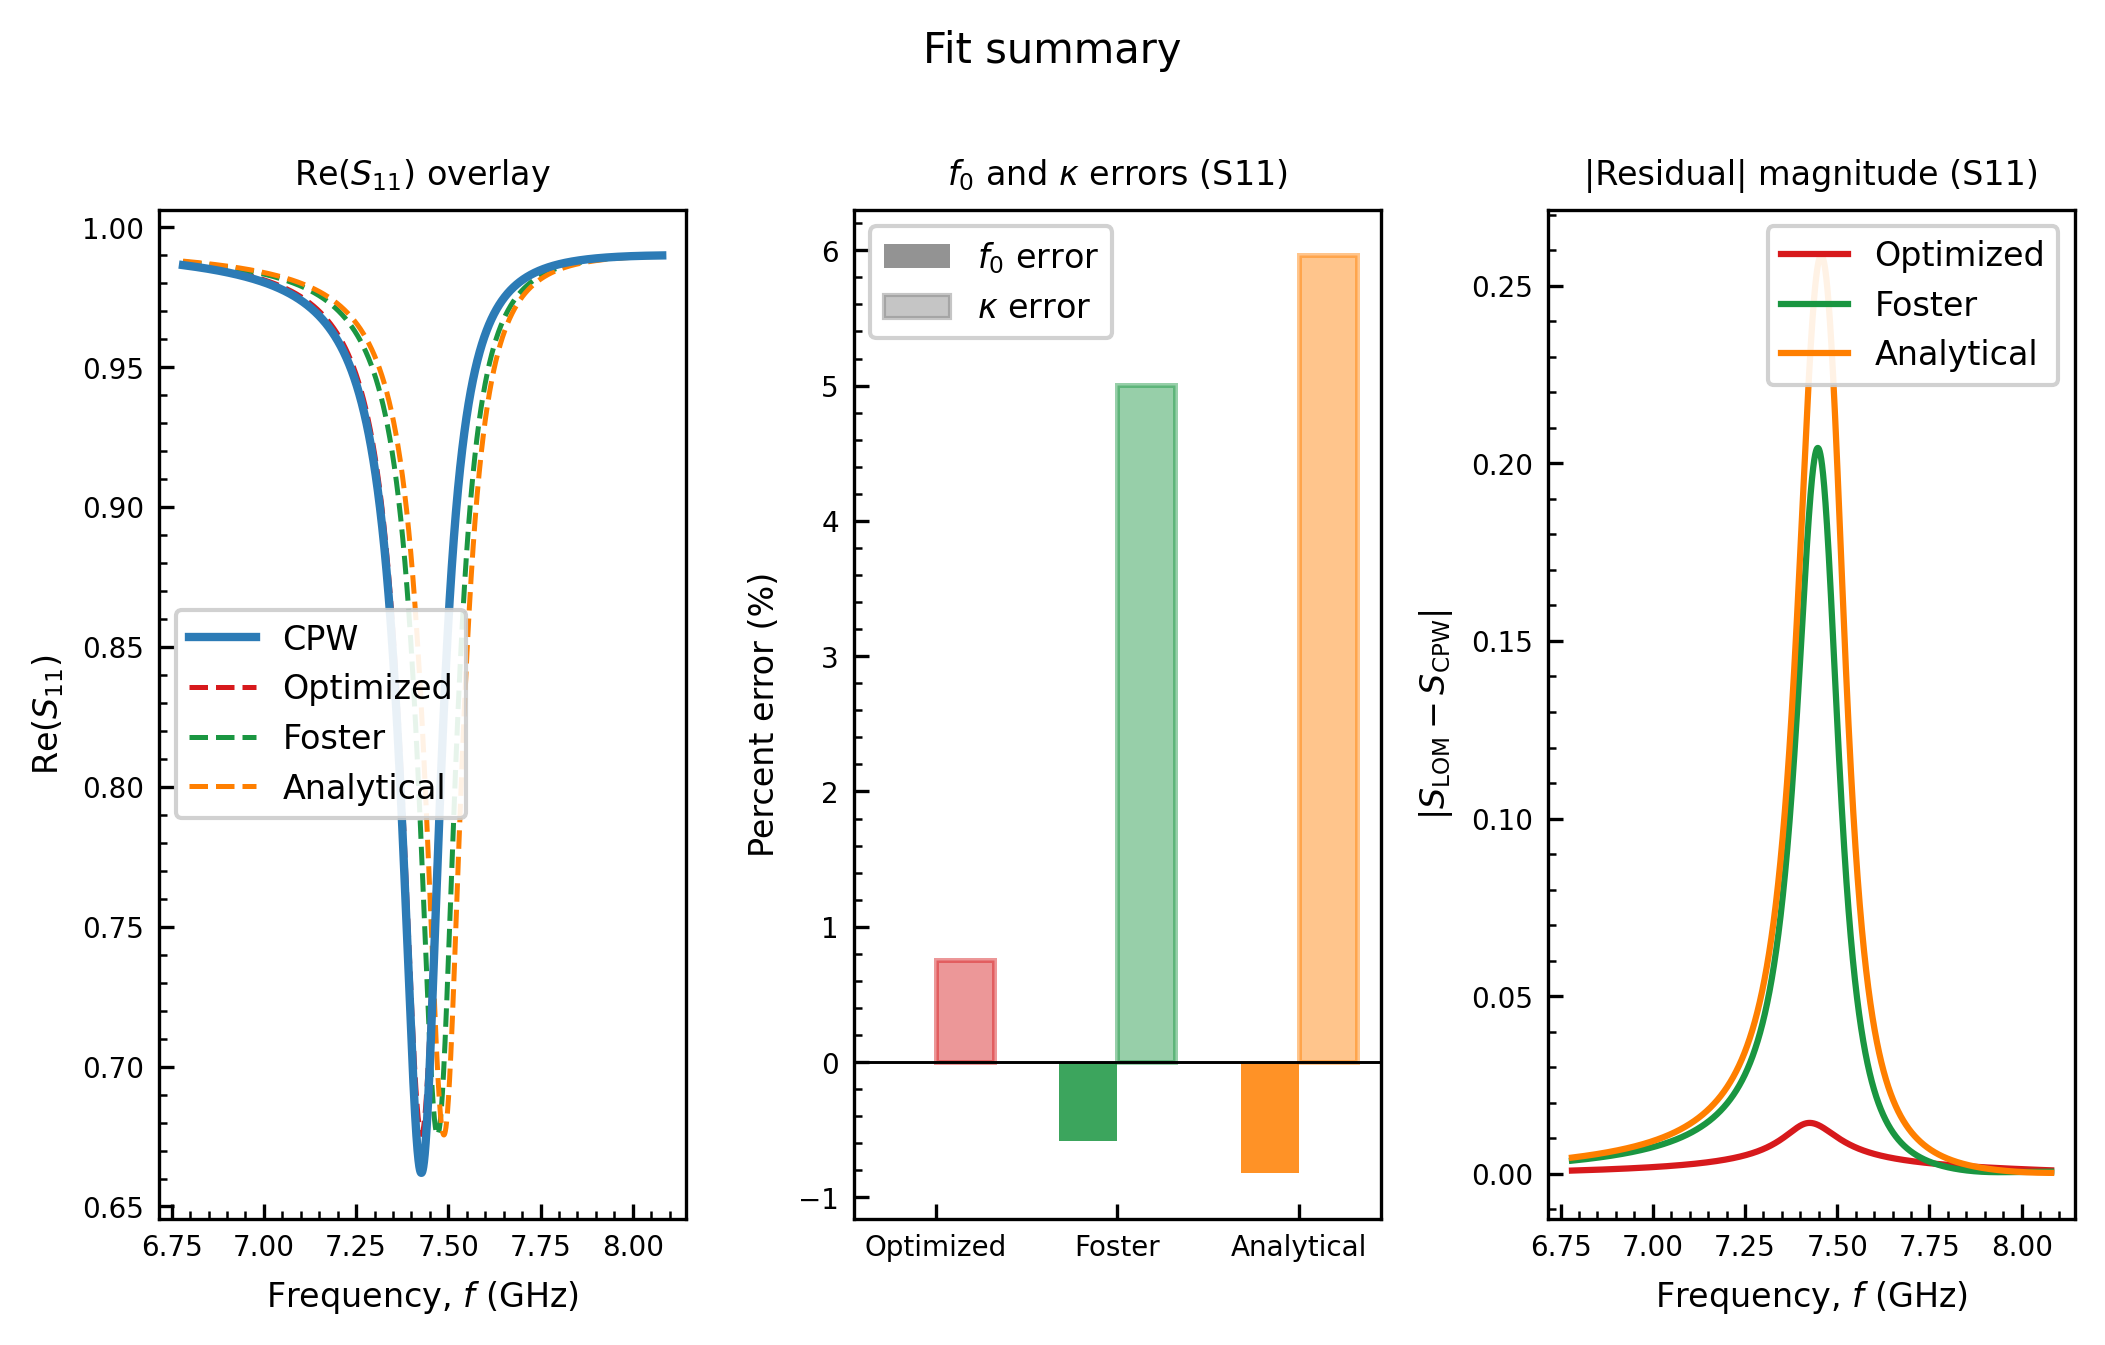

In [20]:
plot_summary(
    results, port="s11",
    title=r"Fit summary",
    save_path="figures/fit_summary.pdf",
)
plt.show()


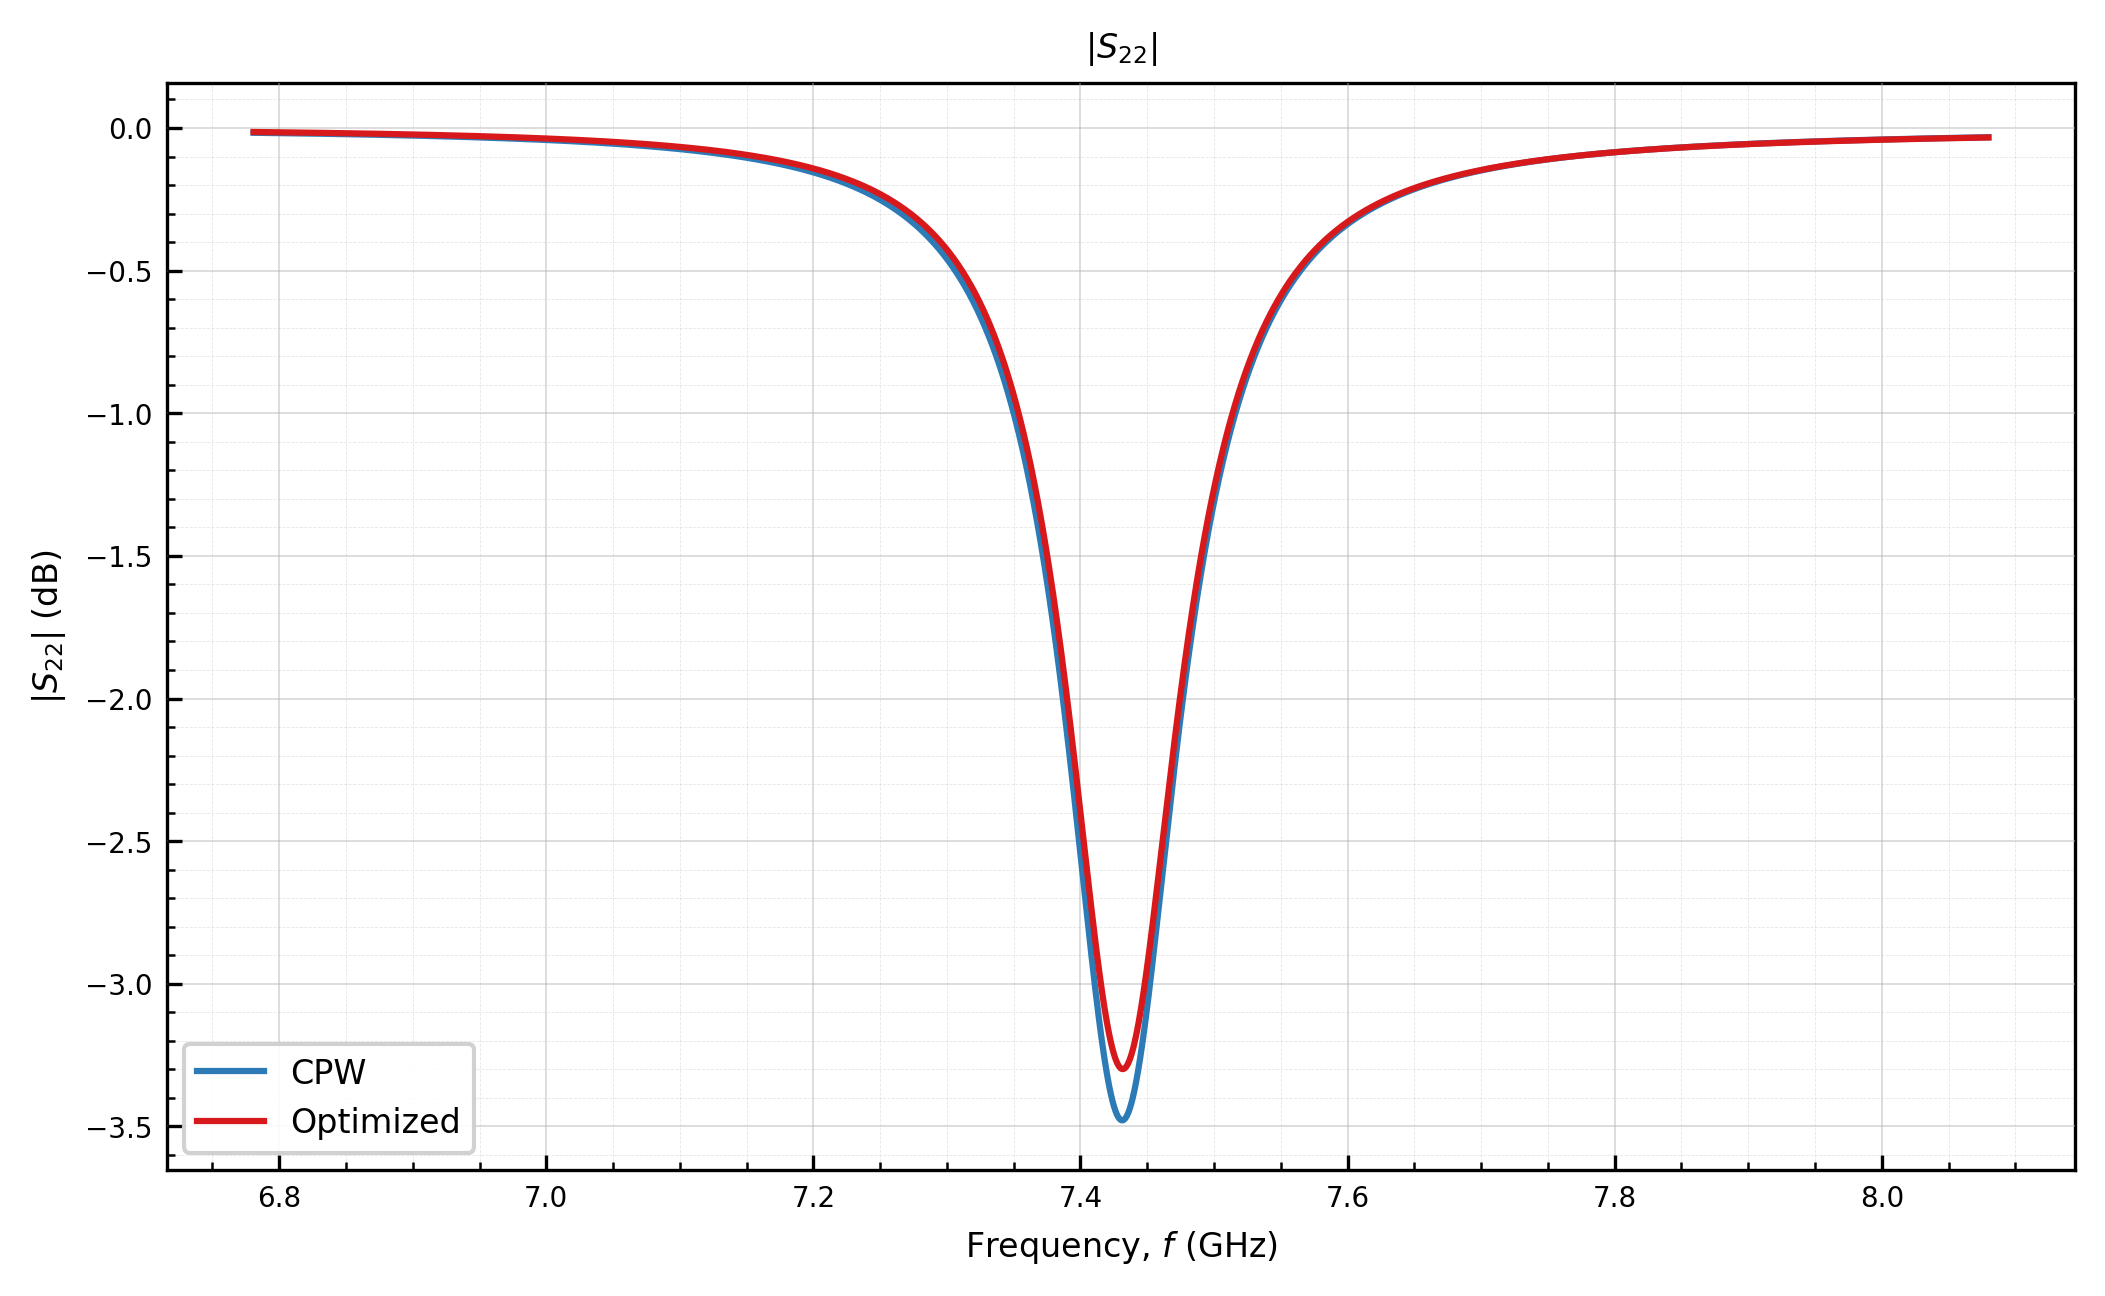

In [21]:
plot_transmission(
    networks={
        "cpw":       results["cpw_network"],
        "optimized": results["optimized_network"],
    },
    m=1, n=1,
)
plt.show()


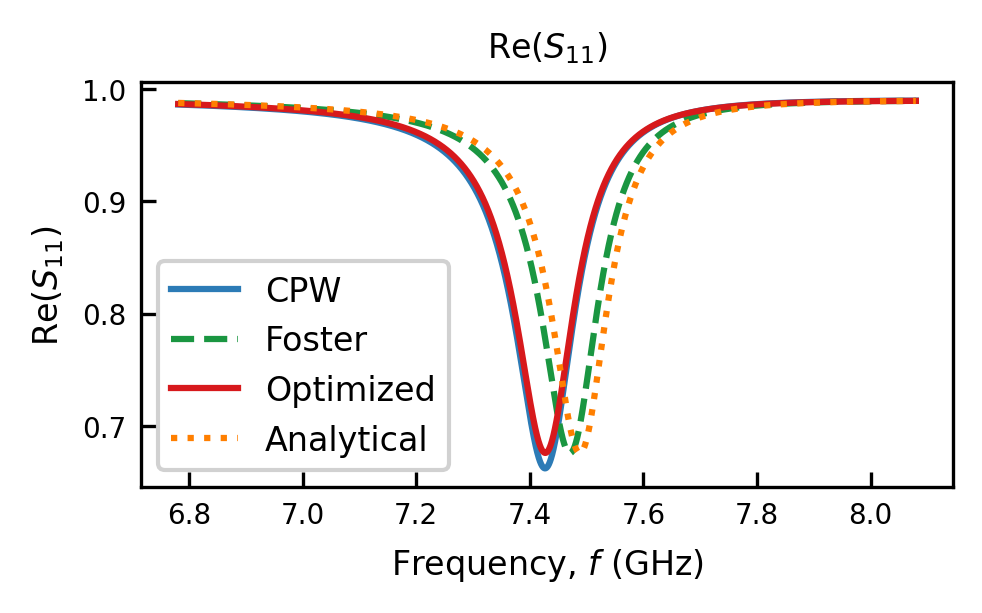

In [22]:
plot_all_models(
    {
        "CPW":        results["cpw_network"],
        "Foster":     results["foster_network"],
        "Optimized":  results["optimized_network"],
        "Analytical": results["analytical_network"],
    },
    m=0, n=0, quantity="re",
    title=r"$\mathrm{Re}(S_{11})$",
)
plt.show()


### 3c. Getting the model parameters

Call `.get_params()` on any fitted model to pull out its effective
$L_\mathrm{eff}, C_\mathrm{eff}$.


In [23]:
print("Optimized :", results["optimized_model"].get_params())
print("Foster    :", results["foster_model"].get_params())
print("Analytical:", results["analytical_model"].get_params())


Optimized : {'L': 5.90935720745428e-10, 'C': 6.780946352532717e-13, 'phase': None, 'scan_results': array([[4.66341850e+10, 6.40216593e-13, 6.21201366e-10, 1.02637034e-02],
       [4.66342340e+10, 6.40039754e-13, 6.21348500e-10, 8.13772276e-03],
       [4.66342831e+10, 6.39861013e-13, 6.21497301e-10, 6.25888651e-03],
       [4.66343322e+10, 6.39680449e-13, 6.21647706e-10, 4.62690759e-03],
       [4.66343813e+10, 6.39497969e-13, 6.21799797e-10, 3.24149601e-03],
       [4.66344304e+10, 6.39313689e-13, 6.21953476e-10, 2.10235884e-03],
       [4.66344795e+10, 6.39127541e-13, 6.22108804e-10, 1.20920020e-03],
       [4.66345286e+10, 6.38939484e-13, 6.22265818e-10, 5.61721220e-04],
       [4.66345777e+10, 6.38749587e-13, 6.22424462e-10, 1.59620110e-04],
       [4.66346268e+10, 6.38557825e-13, 6.22584760e-10, 2.59210091e-06],
       [4.66346758e+10, 6.38364193e-13, 6.22746718e-10, 9.03294653e-05],
       [4.66347249e+10, 6.38168689e-13, 6.22910342e-10, 4.22521514e-04],
       [4.66347740e+10, 6

### 3d. Using `fit_lom` to get `L, C` directly

 When all you need is the
effective `L, C` for a chosen model, you can use the `fit_lom` function. This is the function 
used throughout Tutorials 2–6.


In [24]:
L, C = fit_lom(
    d, model="optimized",
    Cc1=Cc1, Cc2=Cc2, Ctog1=Ctog1, Ctog2=Ctog2,
    cpw_params=cpw_params, freq=refined_freq,
)
f_r = 1.0 / (2 * np.pi * np.sqrt(L * C))
print(f"fit_lom(optimized):  L = {L*1e9:.4f} nH    C = {C*1e15:.2f} fF    f_r = {f_r/1e9:.4f} GHz")


fit_lom(optimized):  L = 0.5909 nH    C = 678.09 fF    f_r = 7.9507 GHz


### 3e. Draw the fitted LC schematic

The same `L, C` drop straight into a schematic. Because `OptimizedFit` folds the
ground capacitances into its effective $(L, C)$, the lumped diagram has **no**
`Ctog` — only the coupling capacitors and the parallel LC tank
(`P1 — Cc1 — [LC] — Cc2 — P2`).


In [25]:
figdir = Path("figures")
figdir.mkdir(exist_ok=True)

sch_lc = lc_schematic_2port(
    L, C, Cc1, Cc2, Z0=Z0,
    annotations={
        "L_nH": round(L * 1e9, 3),
        "C_fF": round(C * 1e15, 2),
        "f_r_GHz": round(f_r / 1e9, 4),
    },
    title="Fitted Optimized LOM",
)
sch_lc.save_svg(figdir / "fitted_lc.svg")
sch_lc.save_html(figdir / "fitted_lc.html")
print("saved figures/fitted_lc.svg|.html")
sch_lc


saved figures/fitted_lc.svg|.html


Schematic(meta={'title': 'Fitted Optimized LOM', 'description': '', 'source': 'simpleLOMs.networks.lc.lc_resonator_network_2port', 'units': {'capacitance': 'F', 'inductance': 'H', 'length': 'm', 'impedance': 'ohm', 'frequency': 'Hz'}}, groups=[{'id': 'resonator', 'label': 'resonator'}], components=[Component(id='P1', type='port', label='Port 1', value='50.00 \\Omega', ports=['out'], group=None, orient='series', props={'Z0': 50.0}), Component(id='Cc1', type='cap', label='C_{c1}', value='30.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 3e-14}), Component(id='LC', type='lc', label='LC', value='L = 590.94 pH\nC = 678.09 fF', ports=['a', 'gnd'], group='resonator', orient='shunt', props={'L': 5.909403168607584e-10, 'C': 6.780886436733167e-13}), Component(id='Cc2', type='cap', label='C_{c2}', value='70.00 fF', ports=['a', 'b'], group=None, orient='series', props={'C': 7e-14}), Component(id='P2', type='port', label='Port 2', value='50.00 \\Omega', ports=['in'], group=None, orient='series', props={'Z0': 50.0})], nets=[Net(id='n1', ports=['P1.out', 'Cc1.a']), Net(id='n2', ports=['Cc1.b', 'LC.a']), Net(id='n3', ports=['LC.gnd', 'GND']), Net(id='n4', ports=['Cc1.b', 'Cc2.a']), Net(id='n5', ports=['Cc2.b', 'P2.in'])], annotations={'L_nH': 0.591, 'C_fF': 678.09, 'f_r_GHz': 7.9507})

When the coupling is strong and asymmetric,
`OptimizedFit` reproduces the distributed response where the closed-form and
Foster models cannot, so it is the default everywhere in `simpleLOMs`.
       
 ## Where to go next

- **Tutorial 2** extends this single-device ranking across the whole coupling
  plane.
- **Tutorial 3** shows how to scale up from one resonator to capacitively-coupled chains,
  reducing each resonator to its fitted LOM.
- **Tutorials 6–7** show how to use the `L, C` parameters to design a single resonator to meet design targets.
